#📌 Extracción

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configurar pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_json('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json')
df

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [5]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


#🔧 Transformación

In [6]:
# Transformar la columna Churn a booleano y asegurar el tipo de dato
df['Churn'] = df['Churn'].map({'Yes': True, 'No': False}).astype(bool)

display(df[['customerID', 'Churn']].head())

,customerID,Churn
0,0002-ORFBO,False
1,0003-MKNFE,False
2,0004-TLHLJ,True
3,0011-IGKFF,True
4,0013-EXCHZ,True


In [7]:
# Expandir la columna 'customer' que contiene diccionarios
customer_columns = pd.json_normalize(df['customer'])

# Concatenar las nuevas columnas y eliminar la original
df = pd.concat([df.drop(columns=['customer']), customer_columns], axis=1)


In [8]:
# Transformar SeniorCitizen a booleano
df['SeniorCitizen'] = df['SeniorCitizen'].astype(bool)

# Verificar el cambio
display(df[['customerID', 'SeniorCitizen']].head())

,customerID,SeniorCitizen
0,0002-ORFBO,False
1,0003-MKNFE,False
2,0004-TLHLJ,False
3,0011-IGKFF,True
4,0013-EXCHZ,True


In [9]:
# Transformar Partner y Dependents a booleano
for col in ['Partner', 'Dependents']:
    df[col] = df[col].map({'Yes': True, 'No': False}).astype(bool)

In [10]:
# Expandir las columnas restantes que contienen diccionarios
for col in ['phone', 'internet', 'account']:
    expanded_cols = pd.json_normalize(df[col])
    df = pd.concat([df.drop(columns=[col]), expanded_cols], axis=1)

display(df.head())

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,False,Female,False,True,True,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,False,Male,False,False,False,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,True,Male,False,False,False,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,True,Male,True,True,False,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,True,Female,True,True,False,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [11]:
# Lista de columnas de servicios de internet a transformar
internet_services = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Transformar a booleano: 'Yes' -> True, otros -> False
for col in internet_services:
    df[col] = df[col].map({'Yes': True, 'No': False, 'No internet service': False}).astype(bool)

In [12]:
# Transformar PhoneService y MultipleLines a booleano
# Para MultipleLines, 'No phone service' se tratará como False
df['PhoneService'] = df['PhoneService'].map({'Yes': True, 'No': False}).astype(bool)
df['MultipleLines'] = df['MultipleLines'].map({'Yes': True, 'No': False, 'No phone service': False}).astype(bool)

In [13]:
# Transformar PaperlessBilling a booleano
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': True, 'No': False}).astype(bool)

In [14]:
df

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,False,Female,False,True,True,9,True,False,DSL,False,True,False,True,True,False,One year,True,Mailed check,65.60,593.3
1,0003-MKNFE,False,Male,False,False,False,9,True,True,DSL,False,False,False,False,False,True,Month-to-month,False,Mailed check,59.90,542.4
2,0004-TLHLJ,True,Male,False,False,False,4,True,False,Fiber optic,False,False,True,False,False,False,Month-to-month,True,Electronic check,73.90,280.85
3,0011-IGKFF,True,Male,True,True,False,13,True,False,Fiber optic,False,True,True,False,True,True,Month-to-month,True,Electronic check,98.00,1237.85
4,0013-EXCHZ,True,Female,True,True,False,3,True,False,Fiber optic,False,False,False,True,True,False,Month-to-month,True,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,False,Female,False,False,False,13,True,False,DSL,True,False,False,True,False,False,One year,False,Mailed check,55.15,742.9
7263,9992-RRAMN,True,Male,False,True,False,22,True,True,Fiber optic,False,False,False,False,False,True,Month-to-month,True,Electronic check,85.10,1873.7
7264,9992-UJOEL,False,Male,False,False,False,2,True,False,DSL,False,True,False,False,False,False,Month-to-month,True,Mailed check,50.30,92.75
7265,9993-LHIEB,False,Male,False,True,True,67,True,False,DSL,True,False,True,True,False,True,Two year,False,Mailed check,67.85,4627.65


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   bool   
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   bool   
 4   Partner           7267 non-null   bool   
 5   Dependents        7267 non-null   bool   
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   bool   
 8   MultipleLines     7267 non-null   bool   
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   bool   
 11  OnlineBackup      7267 non-null   bool   
 12  DeviceProtection  7267 non-null   bool   
 13  TechSupport       7267 non-null   bool   
 14  StreamingTV       7267 non-null   bool   
 15  StreamingMovies   7267 non-null   bool   
 16  Contract          7267 non-null   object 


In [16]:
# Transformar Charges.Total a float, convirtiendo blancos/errores en 0
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce').fillna(0)

In [17]:
# Calcular el cargo diario basado en la facturación mensual (asumiendo mes de 30 días)
df['Cuentas_Diarias'] = df['Charges.Monthly'] / 30

# Mostrar las primeras filas con la nueva columna y los cargos mensuales para comparar
display(df[['customerID', 'Charges.Monthly', 'Cuentas_Diarias']].head())

display(df['Cuentas_Diarias'].describe())

,customerID,Charges.Monthly,Cuentas_Diarias
0,0002-ORFBO,65.6,2.186667
1,0003-MKNFE,59.9,1.996667
2,0004-TLHLJ,73.9,2.463333
3,0011-IGKFF,98.0,3.266667
4,0013-EXCHZ,83.9,2.796667


,Cuentas_Diarias
count,7267.000000
mean,2.157337
std,1.004319
min,0.608333
25%,1.180833
50%,2.343333
75%,2.995833
max,3.958333


In [18]:
df

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,False,Female,False,True,True,9,True,False,DSL,False,True,False,True,True,False,One year,True,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,False,Male,False,False,False,9,True,True,DSL,False,False,False,False,False,True,Month-to-month,False,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,True,Male,False,False,False,4,True,False,Fiber optic,False,False,True,False,False,False,Month-to-month,True,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,True,Male,True,True,False,13,True,False,Fiber optic,False,True,True,False,True,True,Month-to-month,True,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,True,Female,True,True,False,3,True,False,Fiber optic,False,False,False,True,True,False,Month-to-month,True,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,False,Female,False,False,False,13,True,False,DSL,True,False,False,True,False,False,One year,False,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,True,Male,False,True,False,22,True,True,Fiber optic,False,False,False,False,False,True,Month-to-month,True,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,False,Male,False,False,False,2,True,False,DSL,False,True,False,False,False,False,Month-to-month,True,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,False,Male,False,True,True,67,True,False,DSL,True,False,True,True,False,True,Two year,False,Mailed check,67.85,4627.65,2.261667


#📊 Carga y análisis

In [19]:
df.describe()

,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,32.346498,64.720098,2277.182035,2.157337
std,24.571773,30.129572,2268.648587,1.004319
min,0.000000,18.250000,0.000000,0.608333
25%,9.000000,35.425000,396.200000,1.180833
50%,29.000000,70.300000,1389.200000,2.343333
75%,55.000000,89.875000,3778.525000,2.995833
max,72.000000,118.750000,8684.800000,3.958333


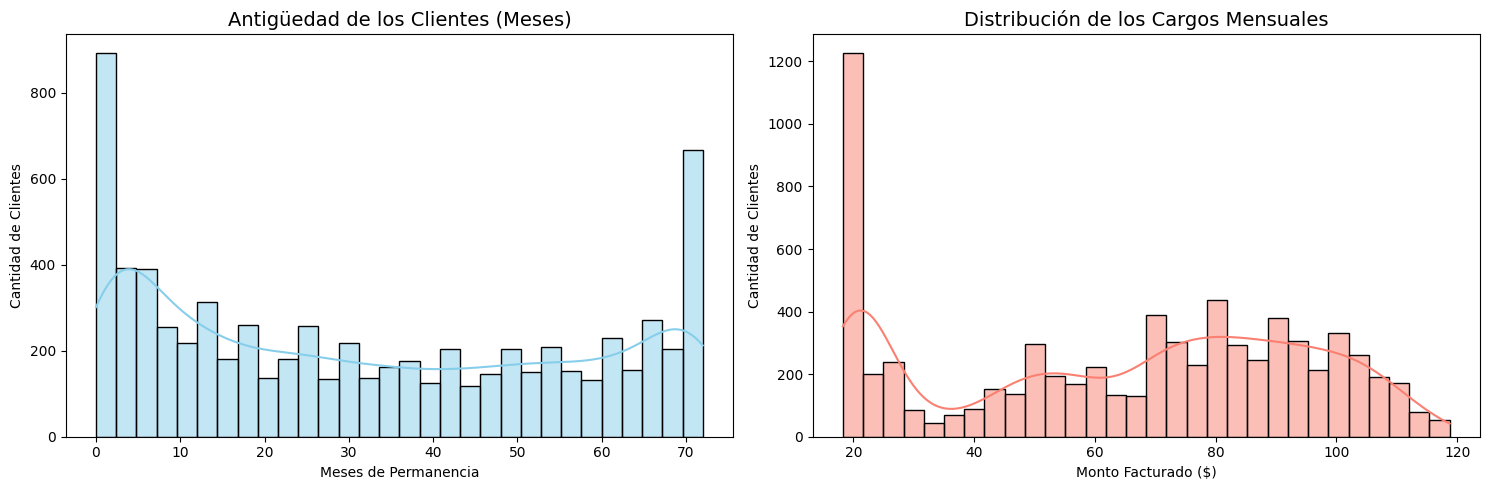

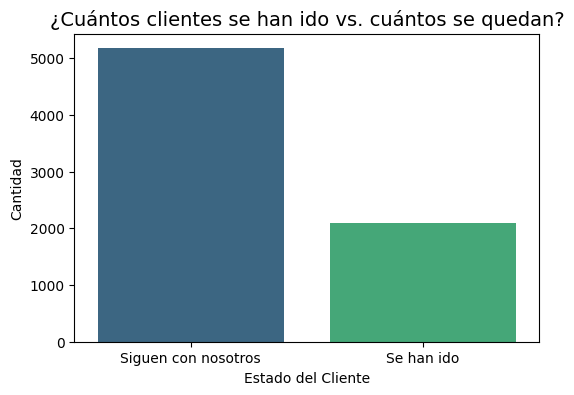

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Visualización de la distribución de variables clave
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución de Tenure
sns.histplot(df['tenure'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Antigüedad de los Clientes (Meses)', fontsize=14)
axes[0].set_xlabel('Meses de Permanencia')
axes[0].set_ylabel('Cantidad de Clientes')

# Distribución de Charges.Monthly
sns.histplot(df['Charges.Monthly'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución de los Cargos Mensuales', fontsize=14)
axes[1].set_xlabel('Monto Facturado ($)')
axes[1].set_ylabel('Cantidad de Clientes')

plt.tight_layout()
plt.show()

# 2. Distribución de Churn (Variable Objetivo)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis', hue='Churn', legend=False)
plt.title('¿Cuántos clientes se han ido vs. cuántos se quedan?', fontsize=14)
plt.xticks([0, 1], ['Siguen con nosotros', 'Se han ido'])
plt.xlabel('Estado del Cliente')
plt.ylabel('Cantidad')
plt.show()

/tmp/ipykernel_463/1316786464.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No', 'Sí'])
/tmp/ipykernel_463/1316786464.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No', 'Sí'])
/tmp/ipykernel_463/1316786464.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No', 'Sí'])


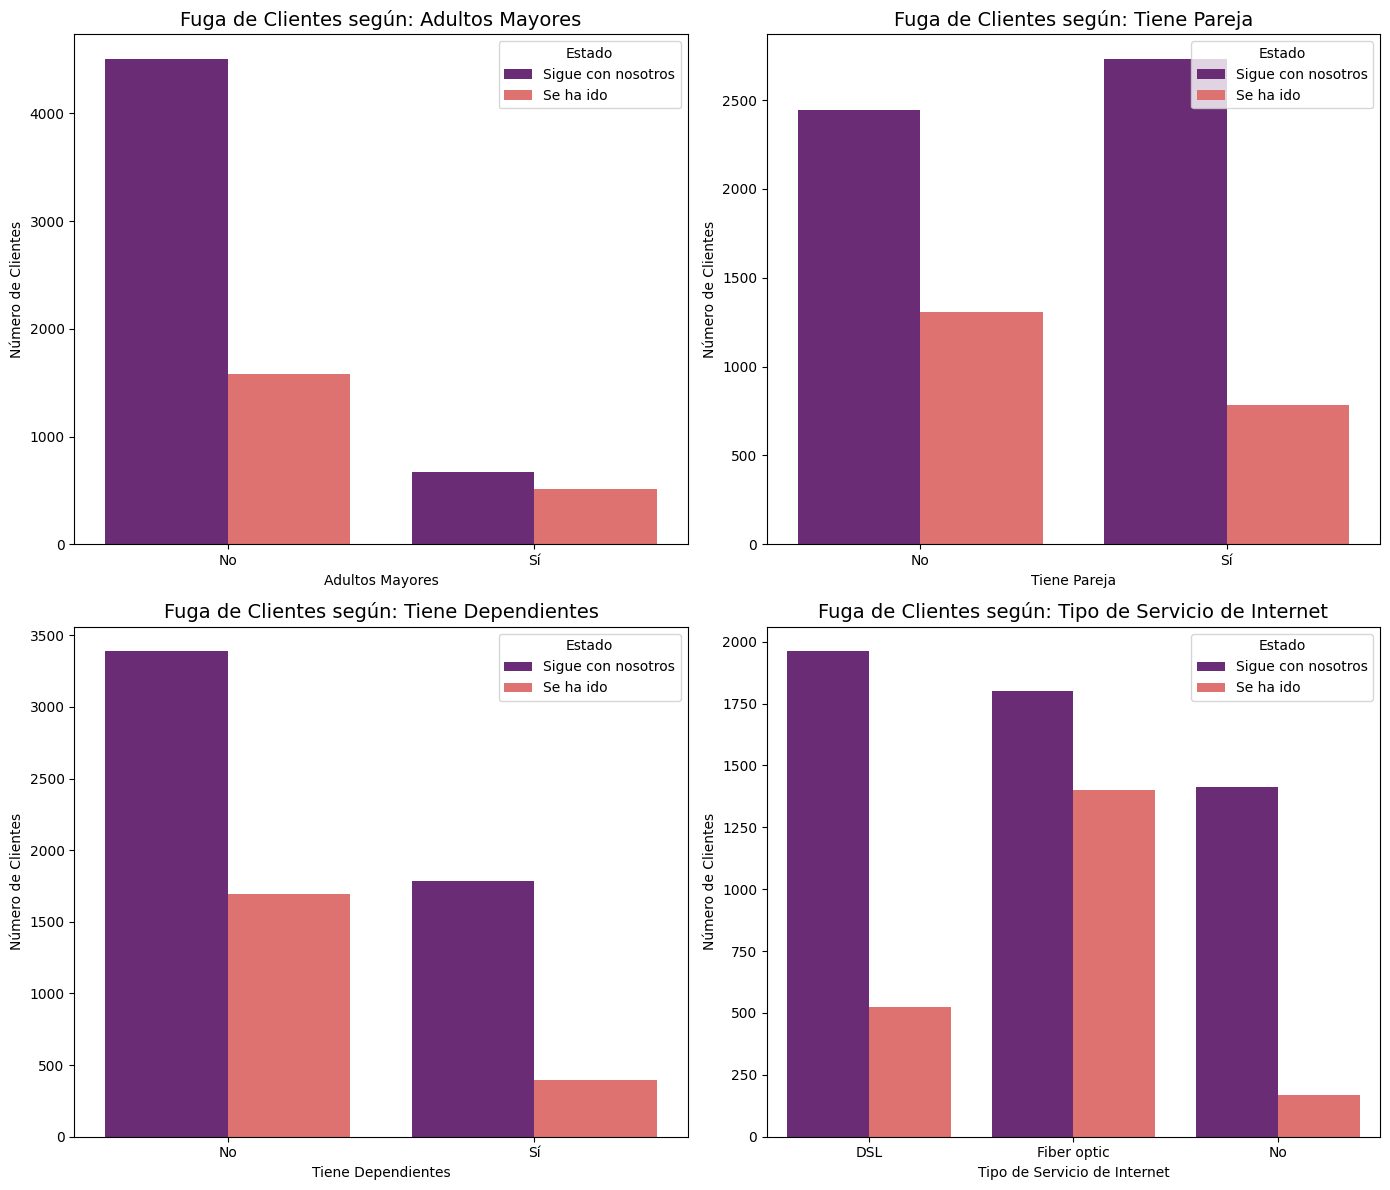

In [21]:
# Definir variables adicionales y mapeos de lenguaje natural
extra_features = ['SeniorCitizen', 'Partner', 'Dependents', 'InternetService']
titles = {
    'SeniorCitizen': 'Adultos Mayores',
    'Partner': 'Tiene Pareja',
    'Dependents': 'Tiene Dependientes',
    'InternetService': 'Tipo de Servicio de Internet'
}

# Crear la figura
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(extra_features):
    ax = sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='magma')
    axes[i].set_title(f'Fuga de Clientes según: {titles[col]}', fontsize=14)
    axes[i].set_xlabel(titles[col])
    axes[i].set_ylabel('Número de Clientes')

    # Traducir etiquetas de los ejes X para booleanos
    if col in ['SeniorCitizen', 'Partner', 'Dependents']:
        axes[i].set_xticklabels(['No', 'Sí'])

    # Ajustar leyenda
    h, l = ax.get_legend_handles_labels()
    ax.legend(h, ['Sigue con nosotros', 'Se ha ido'], title='Estado', loc='upper right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_463/4235528333.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='Churn', ax=axes[i], palette='coolwarm', errorbar=None)
/tmp/ipykernel_463/4235528333.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No', 'Sí'])
/tmp/ipykernel_463/4235528333.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='Churn', ax=axes[i], palette='coolwarm', errorbar=None)
/tmp/ipykernel_463/4235528333.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_

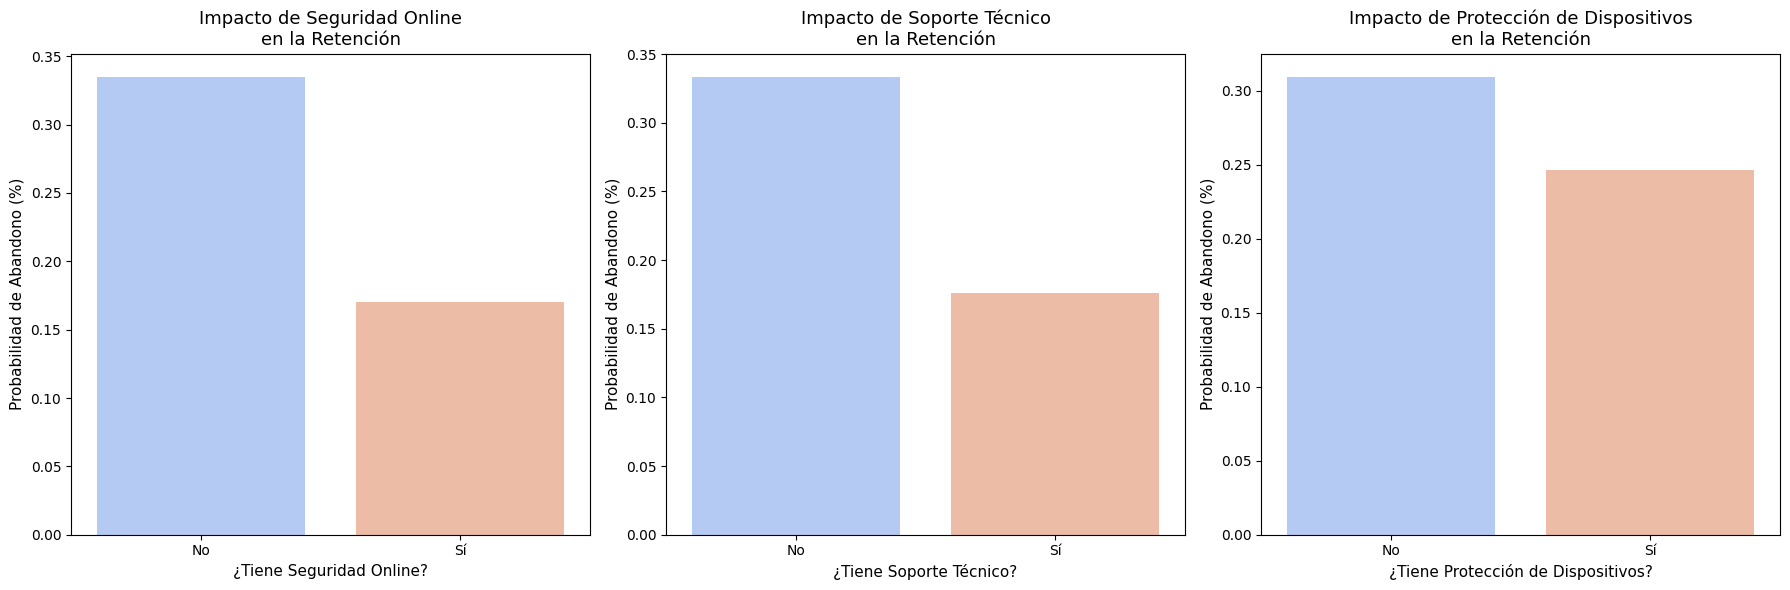

In [22]:
# Visualización de servicios con etiquetas amigables
service_map = {
    'OnlineSecurity': 'Seguridad Online',
    'TechSupport': 'Soporte Técnico',
    'DeviceProtection': 'Protección de Dispositivos'
}

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for i, col in enumerate(service_map.keys()):
    sns.barplot(data=df, x=col, y='Churn', ax=axes[i], palette='coolwarm', errorbar=None)
    axes[i].set_title(f'Impacto de {service_map[col]}\nen la Retención', fontsize=13)
    axes[i].set_xlabel(f'¿Tiene {service_map[col]}?', fontsize=11)
    axes[i].set_ylabel('Probabilidad de Abandono (%)', fontsize=11)
    axes[i].set_xticklabels(['No', 'Sí'])

plt.tight_layout()
plt.show()

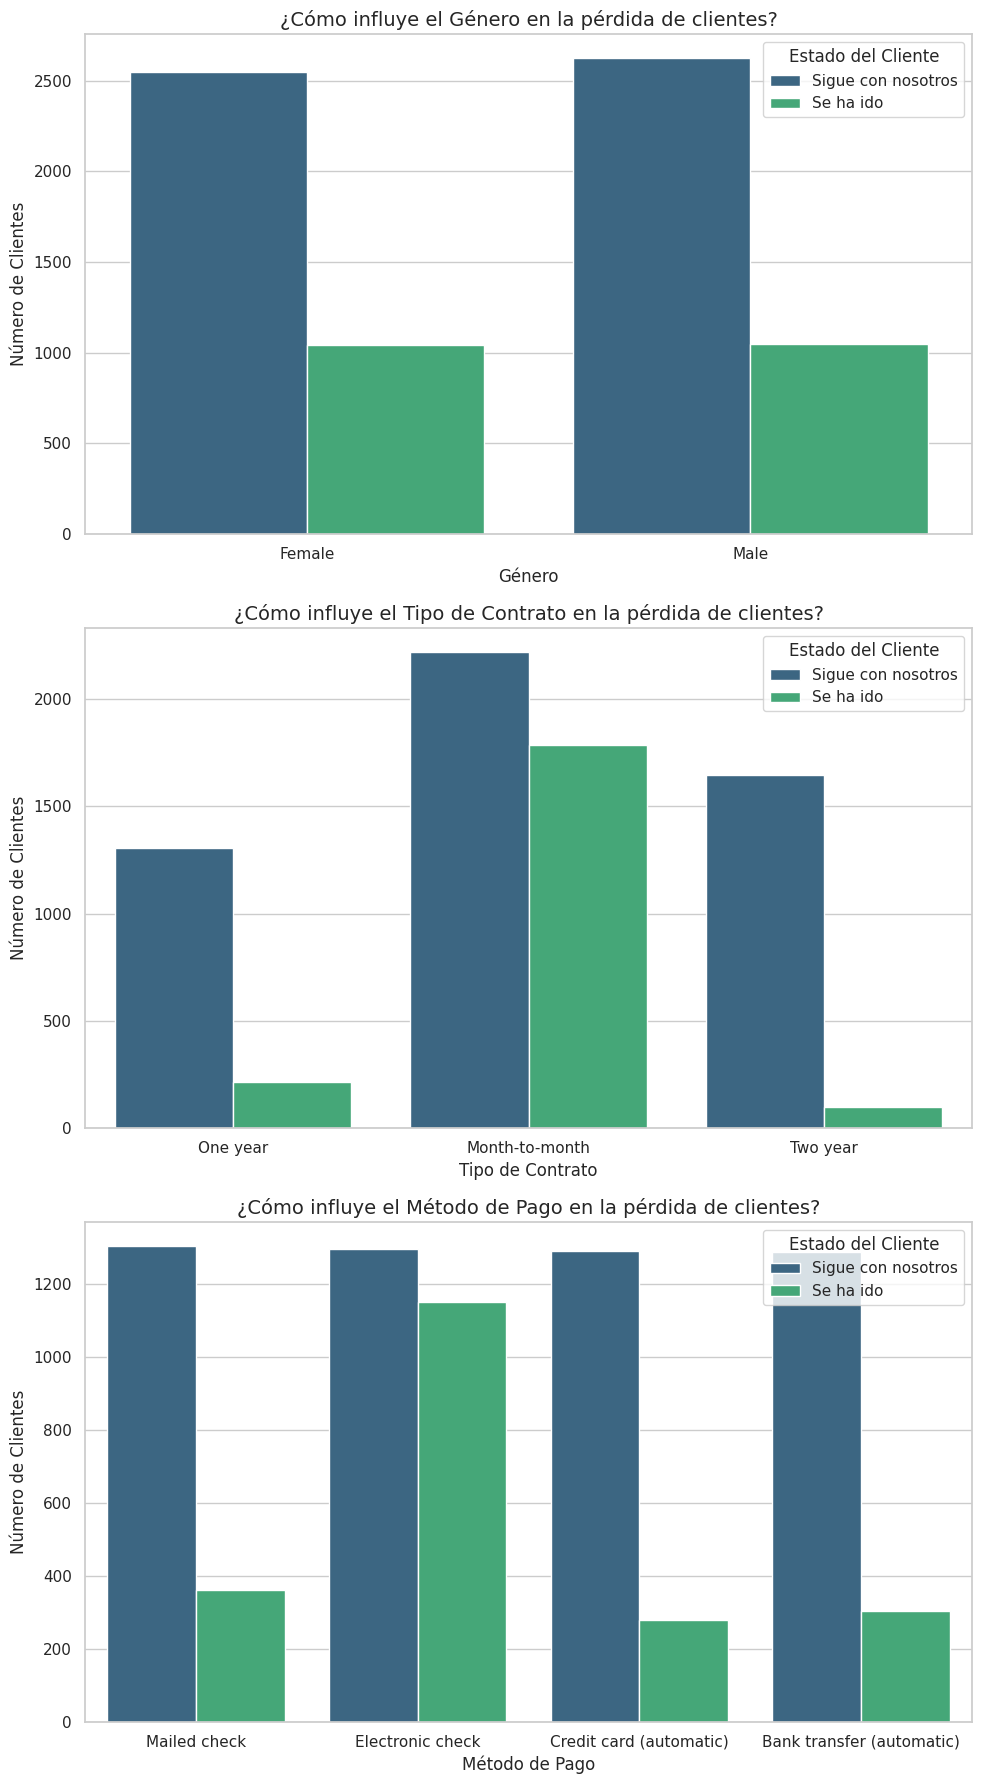

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar el estilo
sns.set_theme(style='whitegrid')

# Diccionario para traducir variables y categorías
traduc_cols = {
    'gender': 'Género',
    'Contract': 'Tipo de Contrato',
    'PaymentMethod': 'Método de Pago',
    'Churn': 'Fuga de Clientes'
}

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 18))

features = ['gender', 'Contract', 'PaymentMethod']
for i, col in enumerate(features):
    ax = sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='viridis')
    axes[i].set_title(f'¿Cómo influye el {traduc_cols[col]} en la pérdida de clientes?', fontsize=14)
    axes[i].set_xlabel(traduc_cols[col], fontsize=12)
    axes[i].set_ylabel('Número de Clientes', fontsize=12)

    # Ajustar leyenda
    legend_labels = ['Sigue con nosotros', 'Se ha ido']
    h, l = ax.get_legend_handles_labels()
    ax.legend(h, legend_labels, title='Estado del Cliente', loc='upper right')

plt.tight_layout()
plt.show()



--- GRUPO 1: DISTRIBUCIONES GENERALES ---




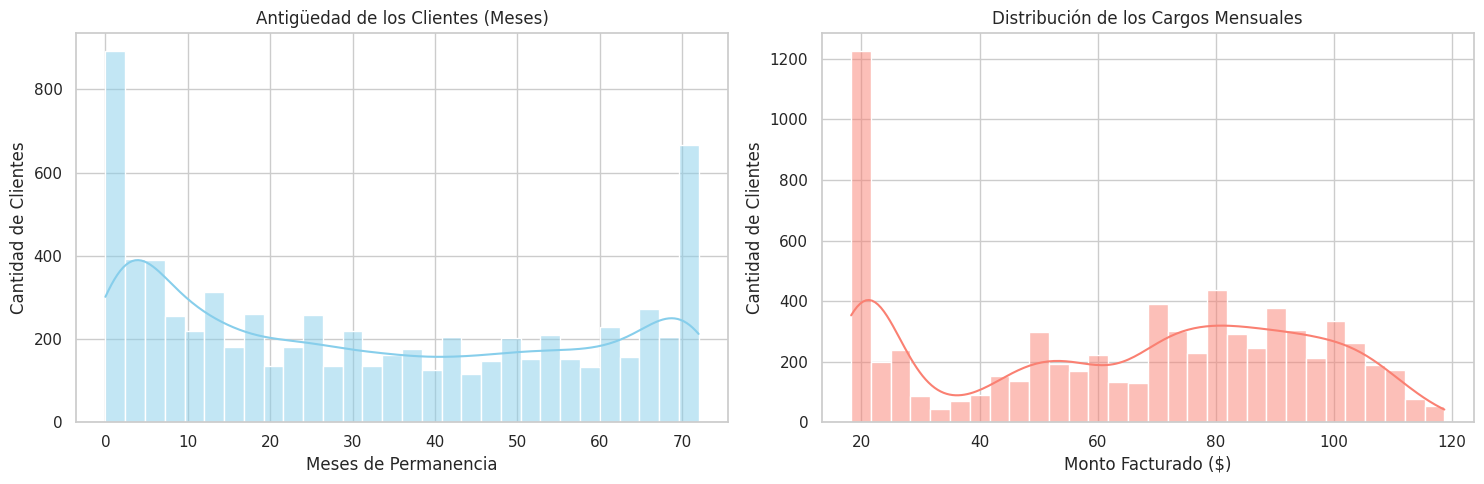



--- GRUPO 2: PERFIL DEMOGRÁFICO Y FUGA ---




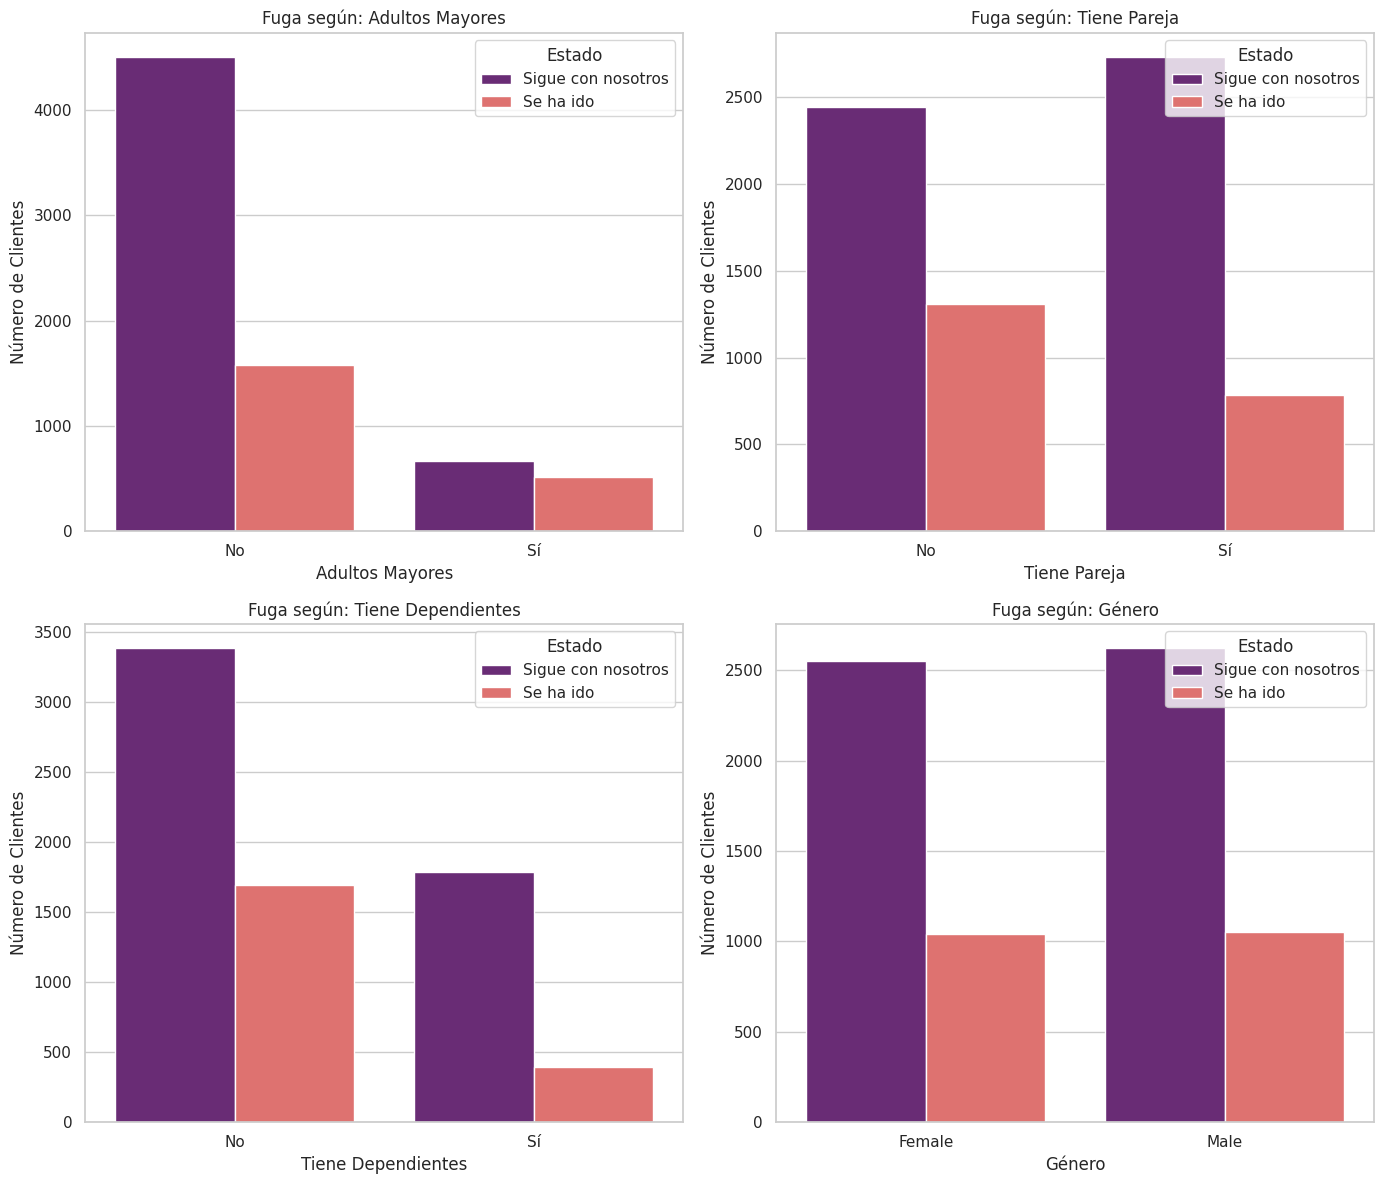



--- GRUPO 3: CONTRATOS, PAGOS Y SERVICIOS ---




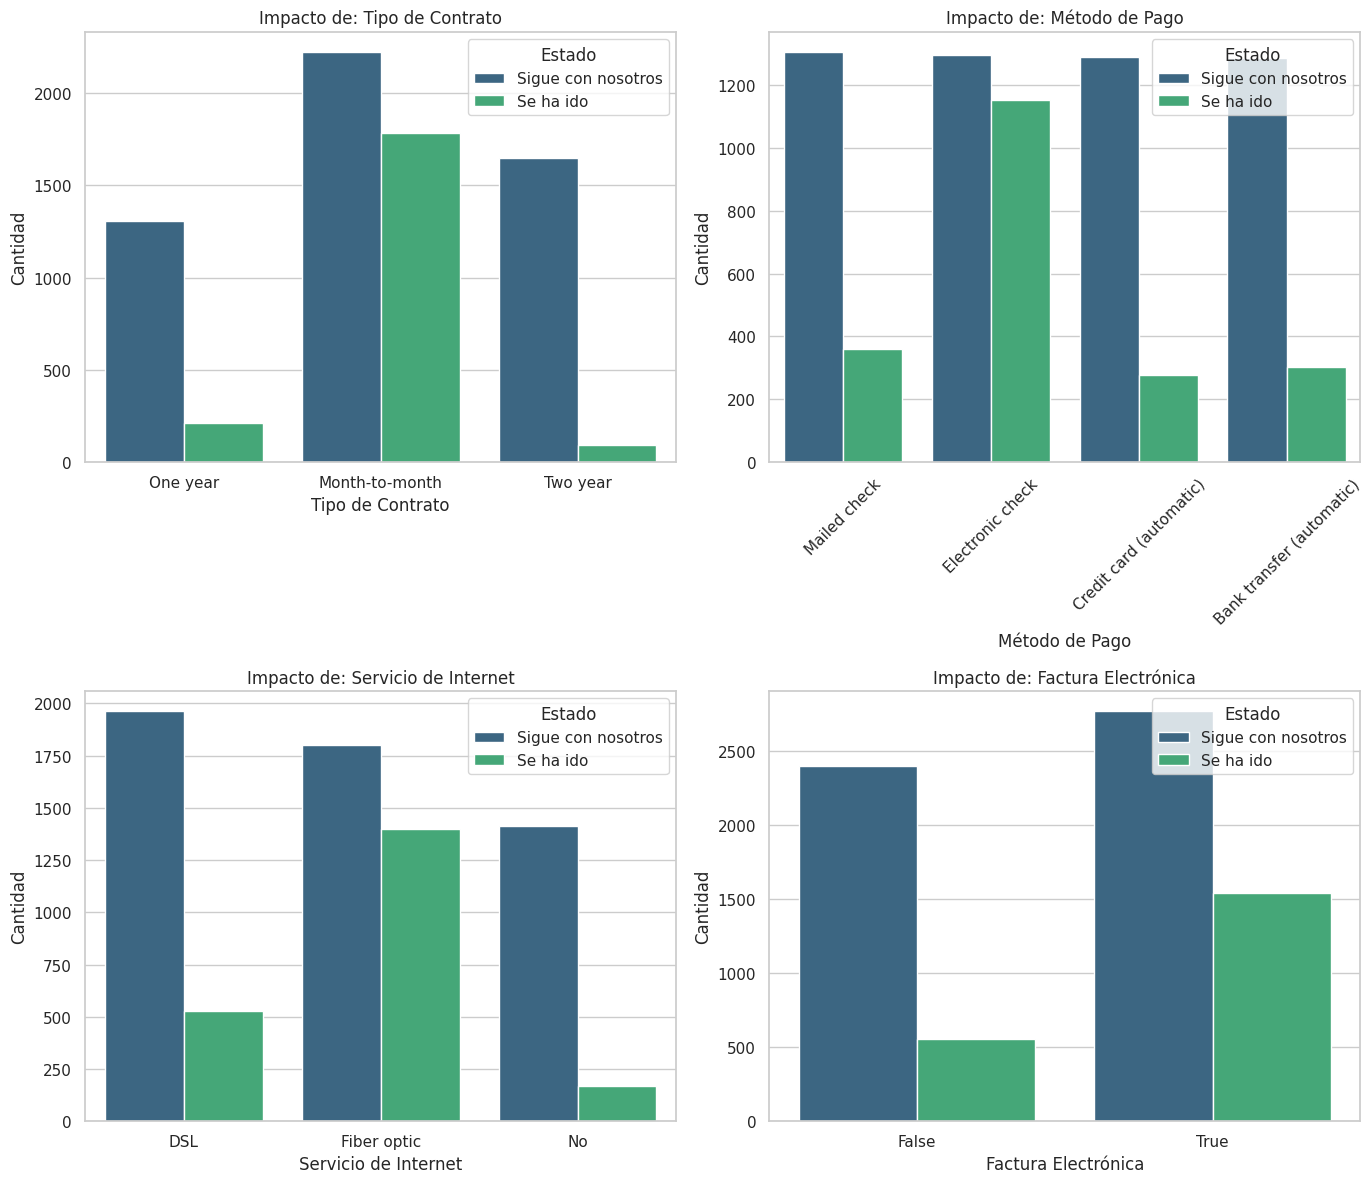

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Desactivar warnings de visualización
warnings.filterwarnings('ignore')

# Configuración estética general
sns.set_theme(style='whitegrid')
plt.rcParams['figure.titlesize'] = 16

print('\n\n--- GRUPO 1: DISTRIBUCIONES GENERALES ---\n\n')
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['tenure'], bins=30, kde=True, ax=axes1[0], color='skyblue')
axes1[0].set_title('Antigüedad de los Clientes (Meses)')
axes1[0].set_xlabel('Meses de Permanencia')
axes1[0].set_ylabel('Cantidad de Clientes')

sns.histplot(df['Charges.Monthly'], bins=30, kde=True, ax=axes1[1], color='salmon')
axes1[1].set_title('Distribución de los Cargos Mensuales')
axes1[1].set_xlabel('Monto Facturado ($)')
axes1[1].set_ylabel('Cantidad de Clientes')

plt.tight_layout()
plt.show()

print('\n\n--- GRUPO 2: PERFIL DEMOGRÁFICO Y FUGA ---\n\n')
extra_features = ['SeniorCitizen', 'Partner', 'Dependents', 'gender']
titles = {
    'SeniorCitizen': 'Adultos Mayores',
    'Partner': 'Tiene Pareja',
    'Dependents': 'Tiene Dependientes',
    'gender': 'Género'
}

fig2, axes2 = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes2 = axes2.flatten()

for i, col in enumerate(extra_features):
    ax = sns.countplot(data=df, x=col, hue='Churn', ax=axes2[i], palette='magma')
    axes2[i].set_title(f'Fuga según: {titles[col]}')
    axes2[i].set_xlabel(titles[col])
    axes2[i].set_ylabel('Número de Clientes')

    if col in ['SeniorCitizen', 'Partner', 'Dependents']:
        axes2[i].set_xticks([0, 1])
        axes2[i].set_xticklabels(['No', 'Sí'])

    h, l = ax.get_legend_handles_labels()
    ax.legend(h, ['Sigue con nosotros', 'Se ha ido'], title='Estado', loc='upper right')

plt.tight_layout()
plt.show()

print('\n\n--- GRUPO 3: CONTRATOS, PAGOS Y SERVICIOS ---\n\n')
fig3, axes3 = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes3 = axes3.flatten()

# Contrato y Pago
service_vars = ['Contract', 'PaymentMethod', 'InternetService', 'PaperlessBilling']
traduc_serv = {
    'Contract': 'Tipo de Contrato',
    'PaymentMethod': 'Método de Pago',
    'InternetService': 'Servicio de Internet',
    'PaperlessBilling': 'Factura Electrónica'
}

for i, col in enumerate(service_vars):
    ax = sns.countplot(data=df, x=col, hue='Churn', ax=axes3[i], palette='viridis')
    axes3[i].set_title(f'Impacto de: {traduc_serv[col]}')
    axes3[i].set_xlabel(traduc_serv[col])
    axes3[i].set_ylabel('Cantidad')
    if col == 'PaymentMethod':
        axes3[i].tick_params(axis='x', rotation=45)

    h, l = ax.get_legend_handles_labels()
    ax.legend(h, ['Sigue con nosotros', 'Se ha ido'], title='Estado')

plt.tight_layout()
plt.show()

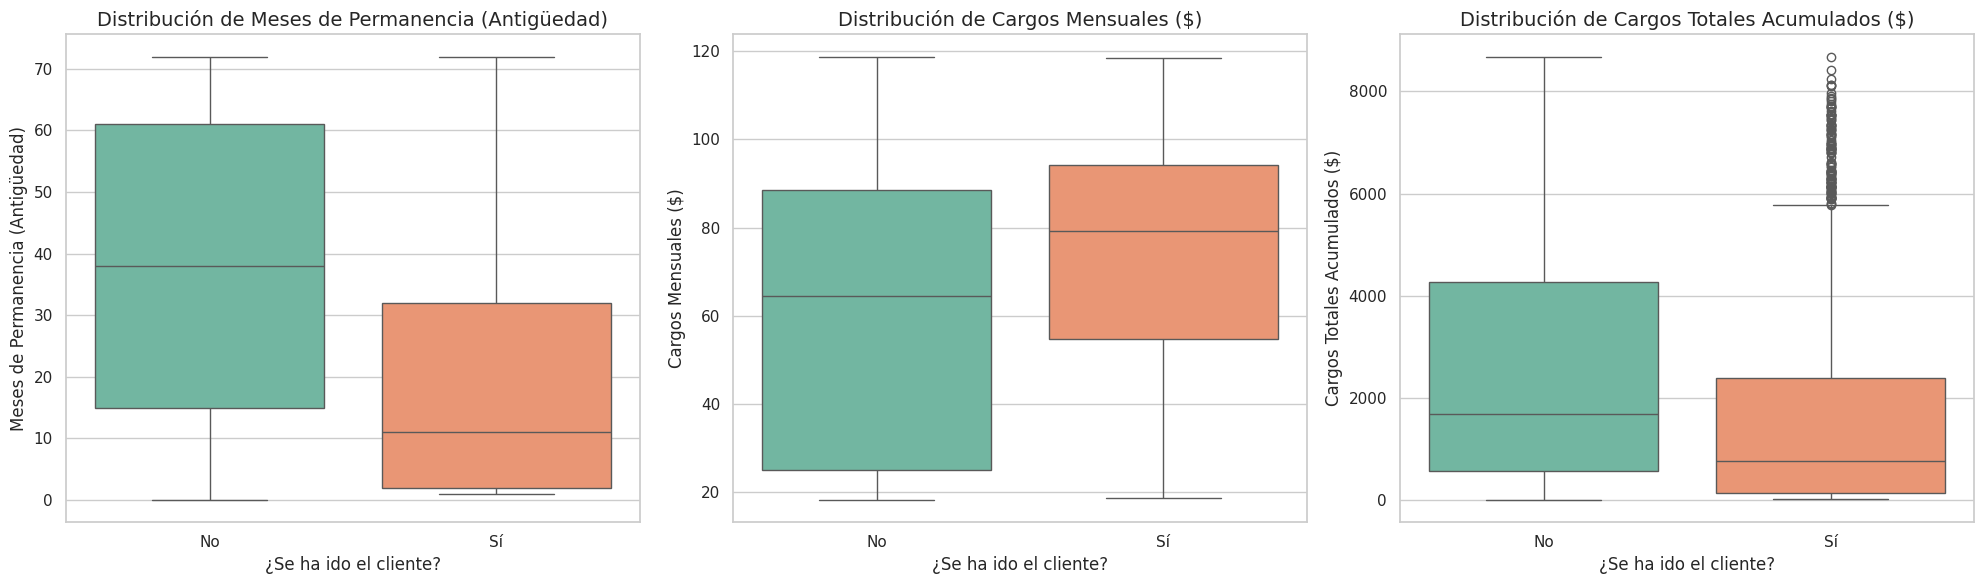

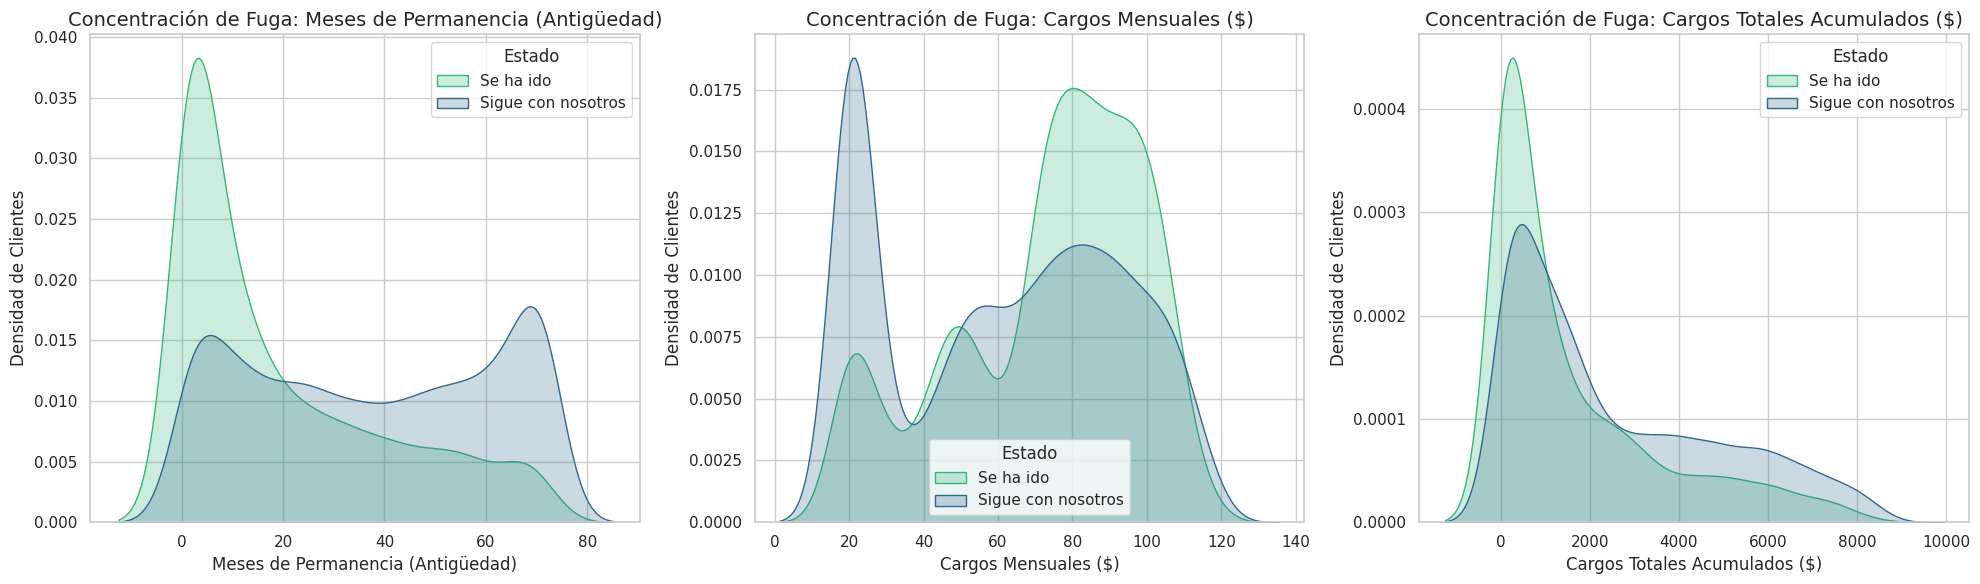

In [25]:
# Configuración de estilo y limpieza de warnings
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Definir variables numéricas clave
numeric_features = ['tenure', 'Charges.Monthly', 'Charges.Total']
traduc_num = {
    'tenure': 'Meses de Permanencia (Antigüedad)',
    'Charges.Monthly': 'Cargos Mensuales ($)',
    'Charges.Total': 'Cargos Totales Acumulados ($)'
}

# Crear visualizaciones comparativas (Boxplots)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

for i, col in enumerate(numeric_features):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribución de {traduc_num[col]}', fontsize=14)
    axes[i].set_xlabel('¿Se ha ido el cliente?', fontsize=12)
    axes[i].set_ylabel(traduc_num[col], fontsize=12)
    axes[i].set_xticklabels(['No', 'Sí'])

plt.tight_layout()
plt.show()

# Análisis de densidad (KDE) para ver dónde se concentra la fuga
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

for i, col in enumerate(numeric_features):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, ax=axes[i], palette='viridis', common_norm=False)
    axes[i].set_title(f'Concentración de Fuga: {traduc_num[col]}', fontsize=14)
    axes[i].set_xlabel(traduc_num[col], fontsize=12)
    axes[i].set_ylabel('Densidad de Clientes', fontsize=12)
    axes[i].legend(title='Estado', labels=['Se ha ido', 'Sigue con nosotros'])

plt.tight_layout()
plt.show()

# 📄 Informe Ejecutivo: Análisis de Fuga de Clientes en TelecomX

## 1. Introducción
El objetivo principal de este análisis es identificar los factores clave que impulsan la pérdida de clientes (**Churn**) en TelecomX. A través del procesamiento de datos históricos de 7,267 usuarios, buscamos transformar datos crudos en hallazgos accionables para desarrollar estrategias de retención personalizadas y reducir la tasa de abandono.

## 2. Metodología y Preparación de Datos
Para garantizar un análisis preciso, se realizaron los siguientes procesos técnicos:
- **Desanidación de Datos**: Se expandieron objetos JSON complejos (`customer`, `phone`, `internet`, `account`) a un formato tabular.
- **Tipado y Limpieza**:
  - Conversión de variables categóricas ('Yes'/'No') a booleanas para optimizar el procesamiento.
  - Transformación de `Charges.Total` a numérico, gestionando valores nulos como 0.
- **Ingeniería de Variables**: Cálculo del cargo diario (`Cuentas_Diarias`) para normalizar el análisis de costos.

## 3. Análisis Exploratorio de Datos (EDA)
Tras visualizar las distribuciones generales, demográficas y de servicios, se identificaron patrones críticos:
- **Distribución de Antigüedad**: Se observa un riesgo de fuga extremadamente alto en los **primeros 6 meses** de permanencia.
- **Impacto Financiero**: Los clientes que cancelan el servicio tienden a tener **cargos mensuales significativamente más altos**.
- **Perfil Demográfico**: Los Adultos Mayores presentan mayor volatilidad, mientras que tener pareja o dependientes actúa como un factor de estabilidad.
- **Tecnología y Pago**: La **Fibra Óptica** y el método de pago por **Cheque Electrónico** están fuertemente correlacionados con una mayor tasa de abandono.

## 4. Conclusiones e Insights
- **Contratos de Corto Plazo**: El contrato 'Mes a Mes' es el principal predictor de fuga. La falta de compromiso a largo plazo facilita la salida del cliente ante cualquier insatisfacción.
- **Servicios de Valor Agregado**: Los clientes que cuentan con **Seguridad Online, Soporte Técnico y Protección de Dispositivos** muestran tasas de churn drásticamente menores, funcionando como 'anclas' de retención.
- **Sensibilidad al Precio**: La fuga se concentra en usuarios con planes costosos de fibra óptica que no perciben un valor proporcional o carecen de servicios de soporte incluidos.

## 5. Recomendaciones Estratégicas
1. **Migración de Contratos**: Implementar campañas de fidelización para transicionar a clientes 'Mes a Mes' hacia contratos anuales mediante descuentos progresivos.
2. **Empaquetamiento de Servicios (Bundling)**: Incluir servicios de Seguridad y Soporte Técnico de forma gratuita o subsidiada en los planes de Fibra Óptica para aumentar el valor percibido.
3. **Optimización de Pagos**: Incentivar el cambio de 'Cheque Electrónico' a métodos automáticos (Tarjeta de Crédito/Débito) mediante bonificaciones únicas, reduciendo la fricción mensual.
4. **Atención Temprana**: Crear un programa de 'Onboarding' para nuevos clientes durante los primeros 3 meses, asegurando que utilicen todos los beneficios del servicio desde el inicio.

In [26]:

df.to_csv("datos_tratados.csv", index=False)


# Preparacion Modelo Predictivo


In [30]:
df1 = pd.read_csv('datos_tratados.csv')
df1

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,False,Female,False,True,True,9,True,False,DSL,False,True,False,True,True,False,One year,True,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,False,Male,False,False,False,9,True,True,DSL,False,False,False,False,False,True,Month-to-month,False,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,True,Male,False,False,False,4,True,False,Fiber optic,False,False,True,False,False,False,Month-to-month,True,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,True,Male,True,True,False,13,True,False,Fiber optic,False,True,True,False,True,True,Month-to-month,True,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,True,Female,True,True,False,3,True,False,Fiber optic,False,False,False,True,True,False,Month-to-month,True,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,False,Female,False,False,False,13,True,False,DSL,True,False,False,True,False,False,One year,False,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,True,Male,False,True,False,22,True,True,Fiber optic,False,False,False,False,False,True,Month-to-month,True,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,False,Male,False,False,False,2,True,False,DSL,False,True,False,False,False,False,Month-to-month,True,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,False,Male,False,True,True,67,True,False,DSL,True,False,True,True,False,True,Two year,False,Mailed check,67.85,4627.65,2.261667


In [31]:
df1.drop(columns=['customerID'], inplace=True)
df1

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,False,Female,False,True,True,9,True,False,DSL,False,True,False,True,True,False,One year,True,Mailed check,65.60,593.30,2.186667
1,False,Male,False,False,False,9,True,True,DSL,False,False,False,False,False,True,Month-to-month,False,Mailed check,59.90,542.40,1.996667
2,True,Male,False,False,False,4,True,False,Fiber optic,False,False,True,False,False,False,Month-to-month,True,Electronic check,73.90,280.85,2.463333
3,True,Male,True,True,False,13,True,False,Fiber optic,False,True,True,False,True,True,Month-to-month,True,Electronic check,98.00,1237.85,3.266667
4,True,Female,True,True,False,3,True,False,Fiber optic,False,False,False,True,True,False,Month-to-month,True,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,False,Female,False,False,False,13,True,False,DSL,True,False,False,True,False,False,One year,False,Mailed check,55.15,742.90,1.838333
7263,True,Male,False,True,False,22,True,True,Fiber optic,False,False,False,False,False,True,Month-to-month,True,Electronic check,85.10,1873.70,2.836667
7264,False,Male,False,False,False,2,True,False,DSL,False,True,False,False,False,False,Month-to-month,True,Mailed check,50.30,92.75,1.676667
7265,False,Male,False,True,True,67,True,False,DSL,True,False,True,True,False,True,Two year,False,Mailed check,67.85,4627.65,2.261667


In [32]:
# Identificar columnas booleanas y convertirlas a entero (0 y 1)
bool_columns = df1.select_dtypes(include=['bool']).columns
df1[bool_columns] = df1[bool_columns].astype(int)

# Verificar los cambios
display(df1.head())
display(df1.info())

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7267 non-null   int64  
 1   gender            7267 non-null   object 
 2   SeniorCitizen     7267 non-null   int64  
 3   Partner           7267 non-null   int64  
 4   Dependents        7267 non-null   int64  
 5   tenure            7267 non-null   int64  
 6   PhoneService      7267 non-null   int64  
 7   MultipleLines     7267 non-null   int64  
 8   InternetService   7267 non-null   object 
 9   OnlineSecurity    7267 non-null   int64  
 10  OnlineBackup      7267 non-null   int64  
 11  DeviceProtection  7267 non-null   int64  
 12  TechSupport       7267 non-null   int64  
 13  StreamingTV       7267 non-null   int64  
 14  StreamingMovies   7267 non-null   int64  
 15  Contract          7267 non-null   object 
 16  PaperlessBilling  7267 non-null   int64  


None

In [33]:
# Diccionarios de codificación para columnas categóricas
# gender: {'Female': 0, 'Male': 1}
# InternetService: {'DSL': 0, 'Fiber optic': 1, 'No': 2}
# Contract: {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
# PaymentMethod: {'Bank transfer (automatic)': 0, 'Credit card (automatic)': 1, 'Electronic check': 2, 'Mailed check': 3}

mapeos = {
    'gender': {'Female': 0, 'Male': 1},
    'InternetService': {'DSL': 0, 'Fiber optic': 1, 'No': 2},
    'Contract': {'Month-to-month': 0, 'One year': 1, 'Two year': 2},
    'PaymentMethod': {
        'Bank transfer (automatic)': 0,
        'Credit card (automatic)': 1,
        'Electronic check': 2,
        'Mailed check': 3
    }
}

# Aplicar los mapeos al DataFrame df1
for col, mapping in mapeos.items():
    df1[col] = df1[col].map(mapping)

# Verificar que ya no queden columnas tipo 'object'
display(df1.head())
display(df1.info())

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0,0,0,1,1,9,1,0,0,0,1,0,1,1,0,1,1,3,65.6,593.30,2.186667
1,0,1,0,0,0,9,1,1,0,0,0,0,0,0,1,0,0,3,59.9,542.40,1.996667
2,1,1,0,0,0,4,1,0,1,0,0,1,0,0,0,0,1,2,73.9,280.85,2.463333
3,1,1,1,1,0,13,1,0,1,0,1,1,0,1,1,0,1,2,98.0,1237.85,3.266667
4,1,0,1,1,0,3,1,0,1,0,0,0,1,1,0,0,1,3,83.9,267.40,2.796667


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7267 non-null   int64  
 1   gender            7267 non-null   int64  
 2   SeniorCitizen     7267 non-null   int64  
 3   Partner           7267 non-null   int64  
 4   Dependents        7267 non-null   int64  
 5   tenure            7267 non-null   int64  
 6   PhoneService      7267 non-null   int64  
 7   MultipleLines     7267 non-null   int64  
 8   InternetService   7267 non-null   int64  
 9   OnlineSecurity    7267 non-null   int64  
 10  OnlineBackup      7267 non-null   int64  
 11  DeviceProtection  7267 non-null   int64  
 12  TechSupport       7267 non-null   int64  
 13  StreamingTV       7267 non-null   int64  
 14  StreamingMovies   7267 non-null   int64  
 15  Contract          7267 non-null   int64  
 16  PaperlessBilling  7267 non-null   int64  


None

--- Análisis de Desbalance de Clases ---
Clientes que se quedan (0): 5174 (71.20%)
Clientes que se van (1):    2093 (28.80%)

Relación de clases: 2.47:1
Estado: Existe un DESBALANCE significativo.
Se recomienda usar métricas como F1-Score o AUC-ROC en lugar de solo Accuracy.




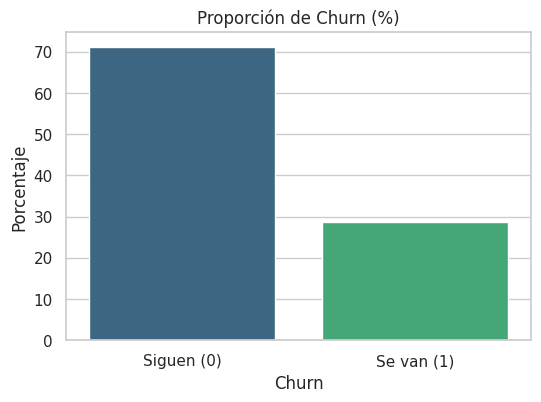

In [37]:
# Calcular la proporción de la variable objetivo Churn
churn_counts = df1['Churn'].value_counts(normalize=True) * 100
churn_abs = df1['Churn'].value_counts()

print("--- Análisis de Desbalance de Clases ---")
print(f"Clientes que se quedan (0): {churn_abs[0]} ({churn_counts[0]:.2f}%)")
print(f"Clientes que se van (1):    {churn_abs[1]} ({churn_counts[1]:.2f}%)")

# Evaluación del desbalance
ratio = churn_abs[0] / churn_abs[1]
print(f"\nRelación de clases: {ratio:.2f}:1")

if ratio > 2:
    print("Estado: Existe un DESBALANCE significativo.\nSe recomienda usar métricas como F1-Score o AUC-ROC en lugar de solo Accuracy.\n\n")
else:
    print("Estado: Las clases están relativamente balanceadas.")

# Visualización rápida para confirmar
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette='viridis')
plt.title('Proporción de Churn (%)')
plt.xticks([0, 1], ['Siguen (0)', 'Se van (1)'])
plt.ylabel('Porcentaje')
plt.show()

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separar características (X) y objetivo (y)
X = df1.drop('Churn', axis=1)
y = df1['Churn']

# 2. Dividir en conjuntos de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")
print("\nDatos listos y escalados.")

Entrenamiento: 5813 muestras
Prueba: 1454 muestras

Datos listos y escalados.


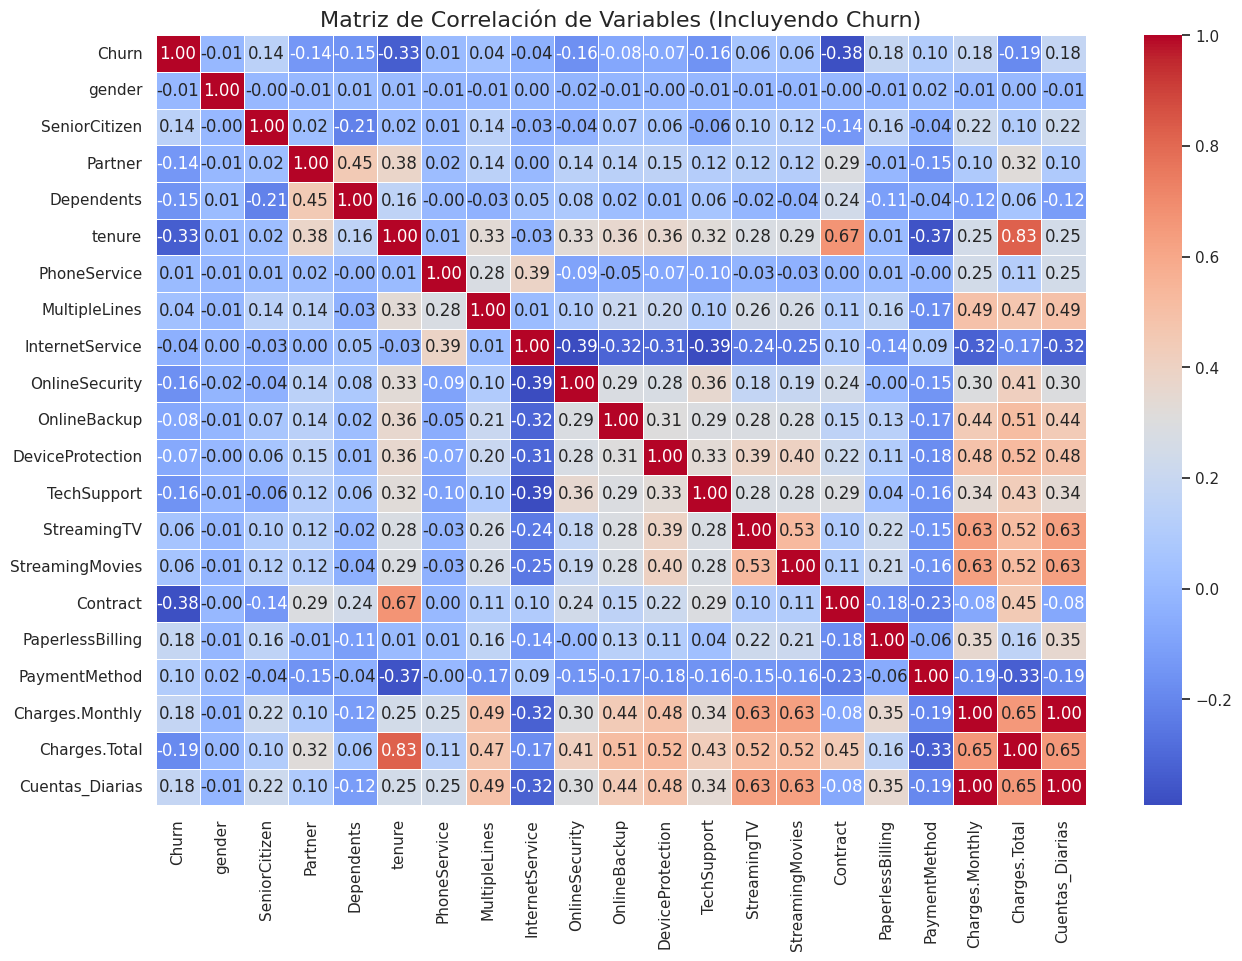

--- Correlación de variables con Churn (Ordenada) ---
Churn               1.000000
PaperlessBilling    0.184575
Cuentas_Diarias     0.180306
Charges.Monthly     0.180306
SeniorCitizen       0.144564
PaymentMethod       0.103714
StreamingTV         0.058384
StreamingMovies     0.056731
MultipleLines       0.037681
PhoneService        0.008845
gender             -0.005137
InternetService    -0.039857
DeviceProtection   -0.066228
OnlineBackup       -0.078771
Partner            -0.138782
Dependents         -0.153268
TechSupport        -0.158111
OnlineSecurity     -0.164422
Charges.Total      -0.189027
tenure             -0.334257
Contract           -0.378433
Name: Churn, dtype: float64


In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de correlación
plt.figure(figsize=(15, 10))
correlation_matrix = df1.corr()

# Crear el mapa de calor
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación de Variables (Incluyendo Churn)', fontsize=16)
plt.show()

# Mostrar específicamente la correlación con la variable objetivo
print("--- Correlación de variables con Churn (Ordenada) ---")
print(correlation_matrix['Churn'].sort_values(ascending=False))

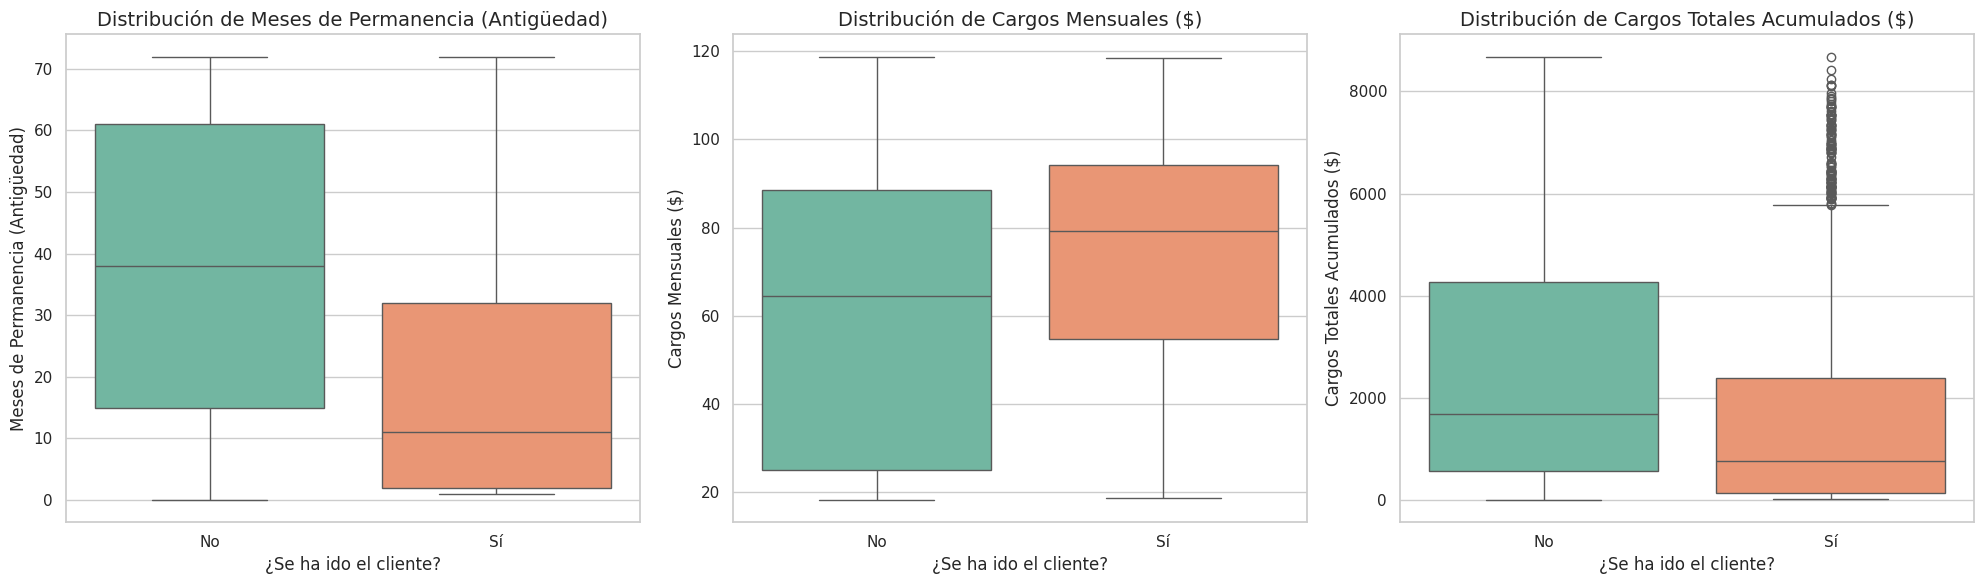

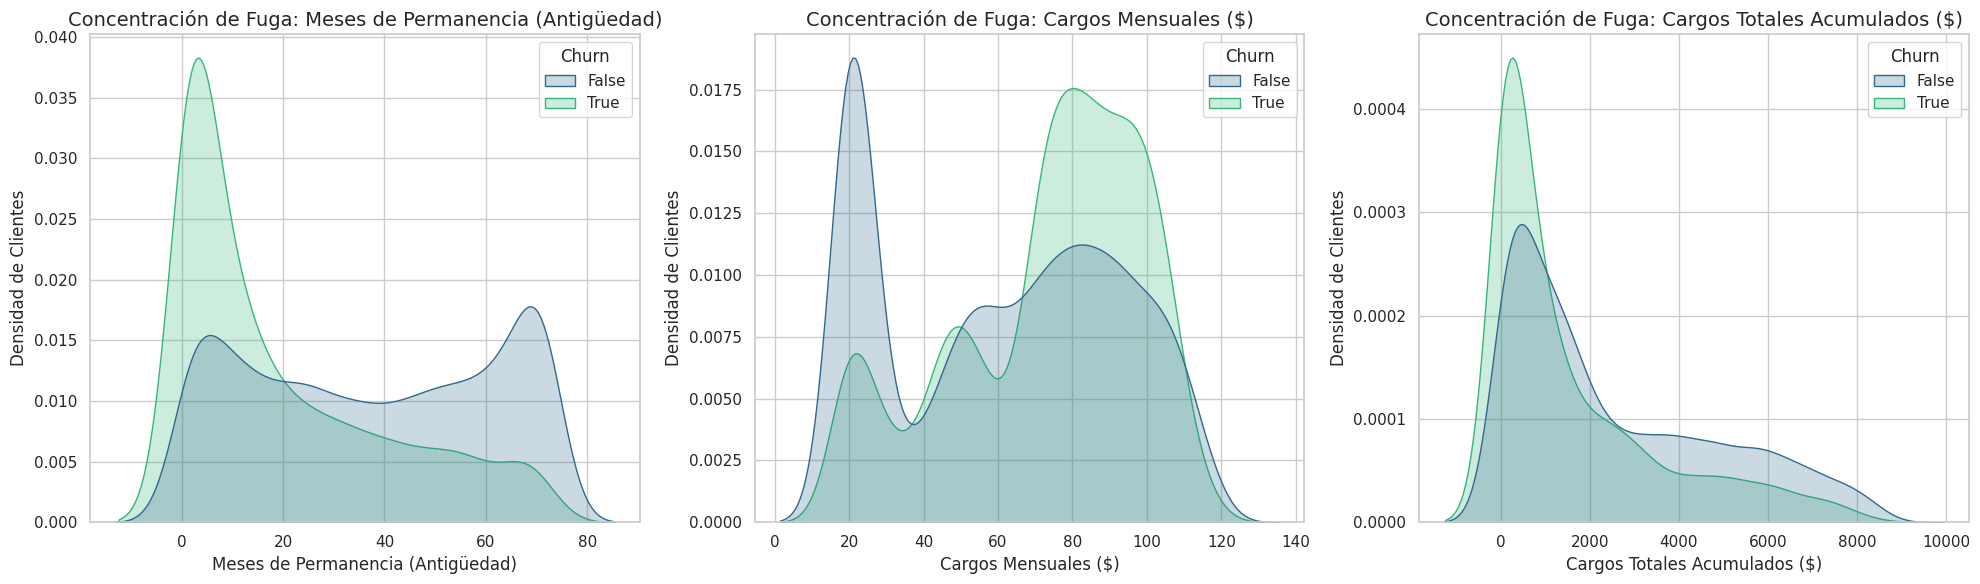

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
sns.set_theme(style='whitegrid')

# Definir variables numéricas clave
numeric_features = ['tenure', 'Charges.Monthly', 'Charges.Total']
traduc_num = {
    'tenure': 'Meses de Permanencia (Antigüedad)',
    'Charges.Monthly': 'Cargos Mensuales ($)',
    'Charges.Total': 'Cargos Totales Acumulados ($)'
}

# 1. Boxplots para comparar distribuciones
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
for i, col in enumerate(numeric_features):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribución de {traduc_num[col]}', fontsize=14)
    axes[i].set_xlabel('¿Se ha ido el cliente?', fontsize=12)
    axes[i].set_ylabel(traduc_num[col], fontsize=12)
    axes[i].set_xticklabels(['No', 'Sí'])

plt.tight_layout()
plt.show()

# 2. KDE Plots para analizar la densidad de la fuga
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
for i, col in enumerate(numeric_features):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, ax=axes[i], palette='viridis', common_norm=False)
    axes[i].set_title(f'Concentración de Fuga: {traduc_num[col]}', fontsize=14)
    axes[i].set_xlabel(traduc_num[col], fontsize=12)
    axes[i].set_ylabel('Densidad de Clientes', fontsize=12)

plt.tight_layout()
plt.show()

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Definir variables independientes (X) y objetivo (y)
X = df1.drop('Churn', axis=1)
y = df1['Churn']

# 2. División 70/30 con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Escalado de los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Registros de Entrenamiento: {X_train.shape[0]}")
print(f"Registros de Prueba: {X_test.shape[0]}")
print("\nConjuntos de datos listos y escalados para la evaluación.")

Registros de Entrenamiento: 5086
Registros de Prueba: 2181

Conjuntos de datos listos y escalados para la evaluación.


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Instanciar el modelo con Pesos de Clase Balanceados
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 2. Entrenar el modelo con los datos escalados
rf_model.fit(X_train_scaled, y_train)

# 3. Realizar predicciones
y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# 4. Evaluar resultados
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}")

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.81      0.87      0.84      1035
           1       0.61      0.49      0.54       419

    accuracy                           0.76      1454
   macro avg       0.71      0.68      0.69      1454
weighted avg       0.75      0.76      0.75      1454

AUC-ROC Score: 0.7793


In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Modelo de Regresión Logística (Requiere normalización/escalado)
log_model = LogisticRegression(class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

print("--- Reporte: Regresión Logística ---")
print(classification_report(y_test, y_pred_log))

# 2. Modelo de Random Forest (No requiere escalado, pero usamos el escalado por consistencia)
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print("\n--- Reporte: Random Forest ---")
print(classification_report(y_test, y_pred_rf))

--- Reporte: Regresión Logística ---
              precision    recall  f1-score   support

           0       0.87      0.70      0.78      1553
           1       0.50      0.74      0.60       628

    accuracy                           0.72      2181
   macro avg       0.69      0.72      0.69      2181
weighted avg       0.77      0.72      0.73      2181


--- Reporte: Random Forest ---
              precision    recall  f1-score   support

           0       0.81      0.87      0.84      1553
           1       0.60      0.48      0.53       628

    accuracy                           0.76      2181
   macro avg       0.70      0.68      0.69      2181
weighted avg       0.75      0.76      0.75      2181



In [44]:
from sklearn.model_selection import GridSearchCV

# 1. Configuración de GridSearchCV para Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# 2. Configuración de GridSearchCV para Regresión Logística
log_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2']
}

grid_log = GridSearchCV(
    LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42),
    log_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# 3. Entrenamiento de las búsquedas
print('Iniciando búsqueda para Random Forest...')
grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_

print('Iniciando búsqueda para Regresión Logística...')
grid_log.fit(X_train_scaled, y_train)
best_log = grid_log.best_estimator_

# 4. Mostrar mejores parámetros encontrados
print('\n--- Mejores Hiperparámetros ---')
print(f'Random Forest: {grid_rf.best_params_}')
print(f'Regresión Logística: {grid_log.best_params_}')

Iniciando búsqueda para Random Forest...
Iniciando búsqueda para Regresión Logística...

--- Mejores Hiperparámetros ---
Random Forest: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Regresión Logística: {'C': 1, 'penalty': 'l1'}


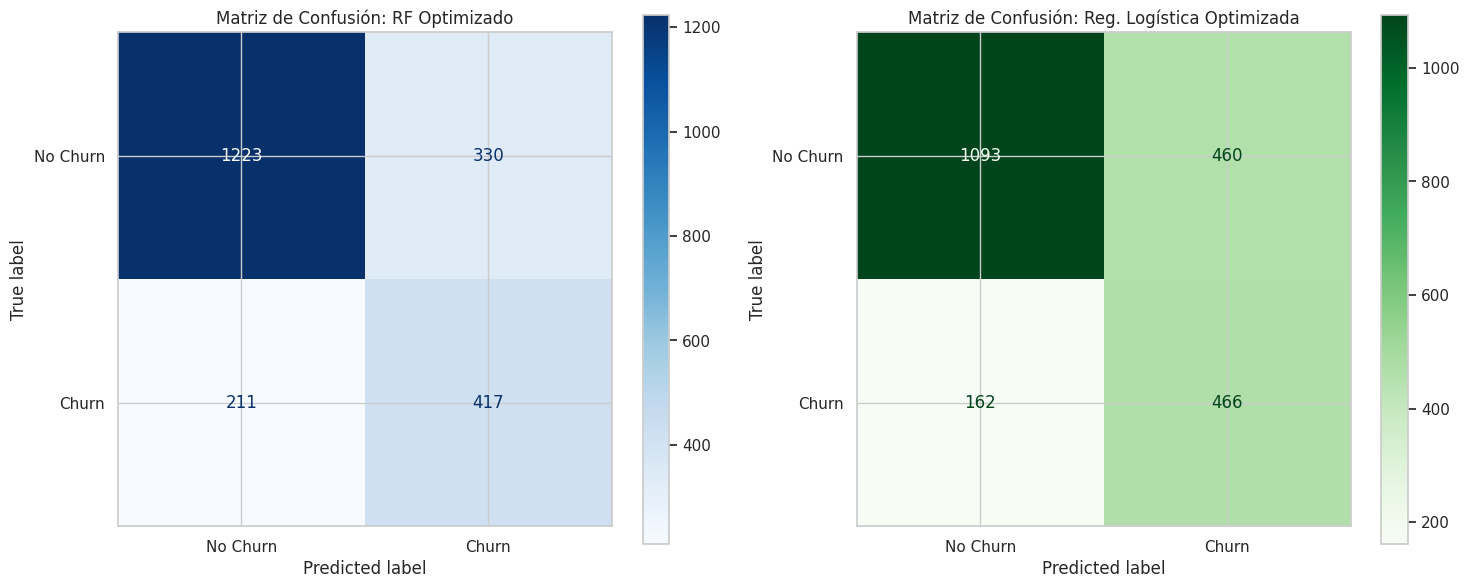

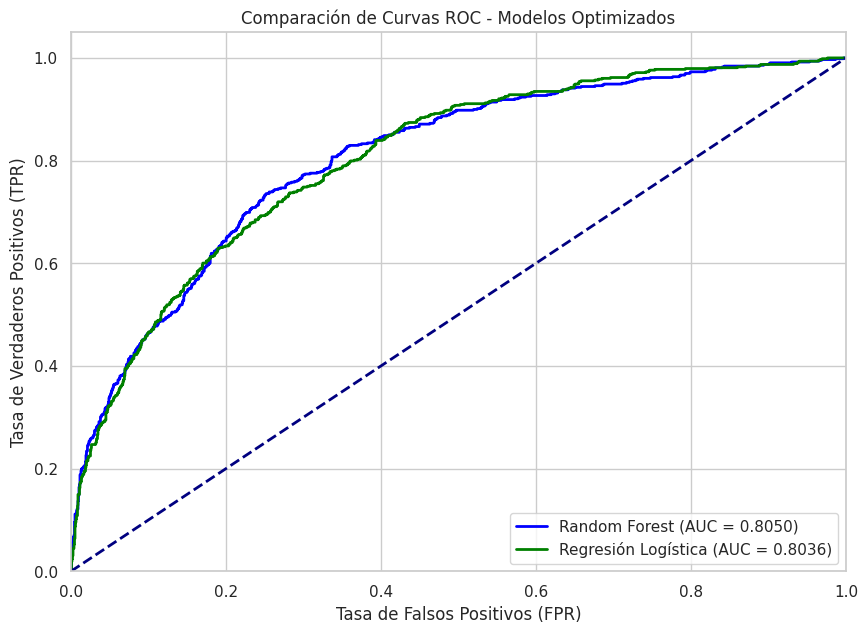

--- Comparativa de Métricas (Clase 1: Churn) ---
RF Optimizado - Recall: 0.6640, F1: 0.6065
Logística Optimizada - Recall: 0.7420, F1: 0.5997


In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, f1_score, recall_score
import matplotlib.pyplot as plt

# 1. Generar predicciones y probabilidades para los modelos optimizados
y_pred_rf_opt = best_rf.predict(X_test_scaled)
y_prob_rf_opt = best_rf.predict_proba(X_test_scaled)[:, 1]

y_pred_log_opt = best_log.predict(X_test_scaled)
y_prob_log_opt = best_log.predict_proba(X_test_scaled)[:, 1]

# 2. Visualizar Matrices de Confusión
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ConfusionMatrixDisplay.from_estimator(best_rf, X_test_scaled, y_test,
                                      display_labels=['No Churn', 'Churn'],
                                      cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión: RF Optimizado')

ConfusionMatrixDisplay.from_estimator(best_log, X_test_scaled, y_test,
                                      display_labels=['No Churn', 'Churn'],
                                      cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de Confusión: Reg. Logística Optimizada')

plt.tight_layout()
plt.show()

# 3. Graficar Curvas ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf_opt)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log_opt)
roc_auc_log = auc(fpr_log, tpr_log)

plt.figure(figsize=(10, 7))
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.plot(fpr_log, tpr_log, color='green', lw=2, label=f'Regresión Logística (AUC = {roc_auc_log:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Comparación de Curvas ROC - Modelos Optimizados')
plt.legend(loc="lower right")
plt.show()

# 4. Comparativa rápida de métricas clave (Recall y F1 para clase 1)
print('--- Comparativa de Métricas (Clase 1: Churn) ---')
print(f'RF Optimizado - Recall: {recall_score(y_test, y_pred_rf_opt):.4f}, F1: {f1_score(y_test, y_pred_rf_opt):.4f}')
print(f'Logística Optimizada - Recall: {recall_score(y_test, y_pred_log_opt):.4f}, F1: {f1_score(y_test, y_pred_log_opt):.4f}')

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Aplicando los mejores parámetros encontrados en la evaluación

# 1. Random Forest Optimizado
# Parámetros: max_depth=10, min_samples_split=10, n_estimators=200
final_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)
final_rf_model.fit(X_train_scaled, y_train)
y_pred_rf_final = final_rf_model.predict(X_test_scaled)

# 2. Regresión Logística Optimizada
# Parámetros: C=1, penalty='l1', solver='liblinear'
final_log_model = LogisticRegression(
    C=1,
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    random_state=42
)
final_log_model.fit(X_train_scaled, y_train)
y_pred_log_final = final_log_model.predict(X_test_scaled)

print("--- Reporte Final: Random Forest Optimizado ---")
print(classification_report(y_test, y_pred_rf_final))

print("\n--- Reporte Final: Regresión Logística Optimizada ---")
print(classification_report(y_test, y_pred_log_final))

--- Reporte Final: Random Forest Optimizado ---
              precision    recall  f1-score   support

           0       0.85      0.79      0.82      1553
           1       0.56      0.66      0.61       628

    accuracy                           0.75      2181
   macro avg       0.71      0.73      0.71      2181
weighted avg       0.77      0.75      0.76      2181


--- Reporte Final: Regresión Logística Optimizada ---
              precision    recall  f1-score   support

           0       0.87      0.70      0.78      1553
           1       0.50      0.74      0.60       628

    accuracy                           0.71      2181
   macro avg       0.69      0.72      0.69      2181
weighted avg       0.77      0.71      0.73      2181



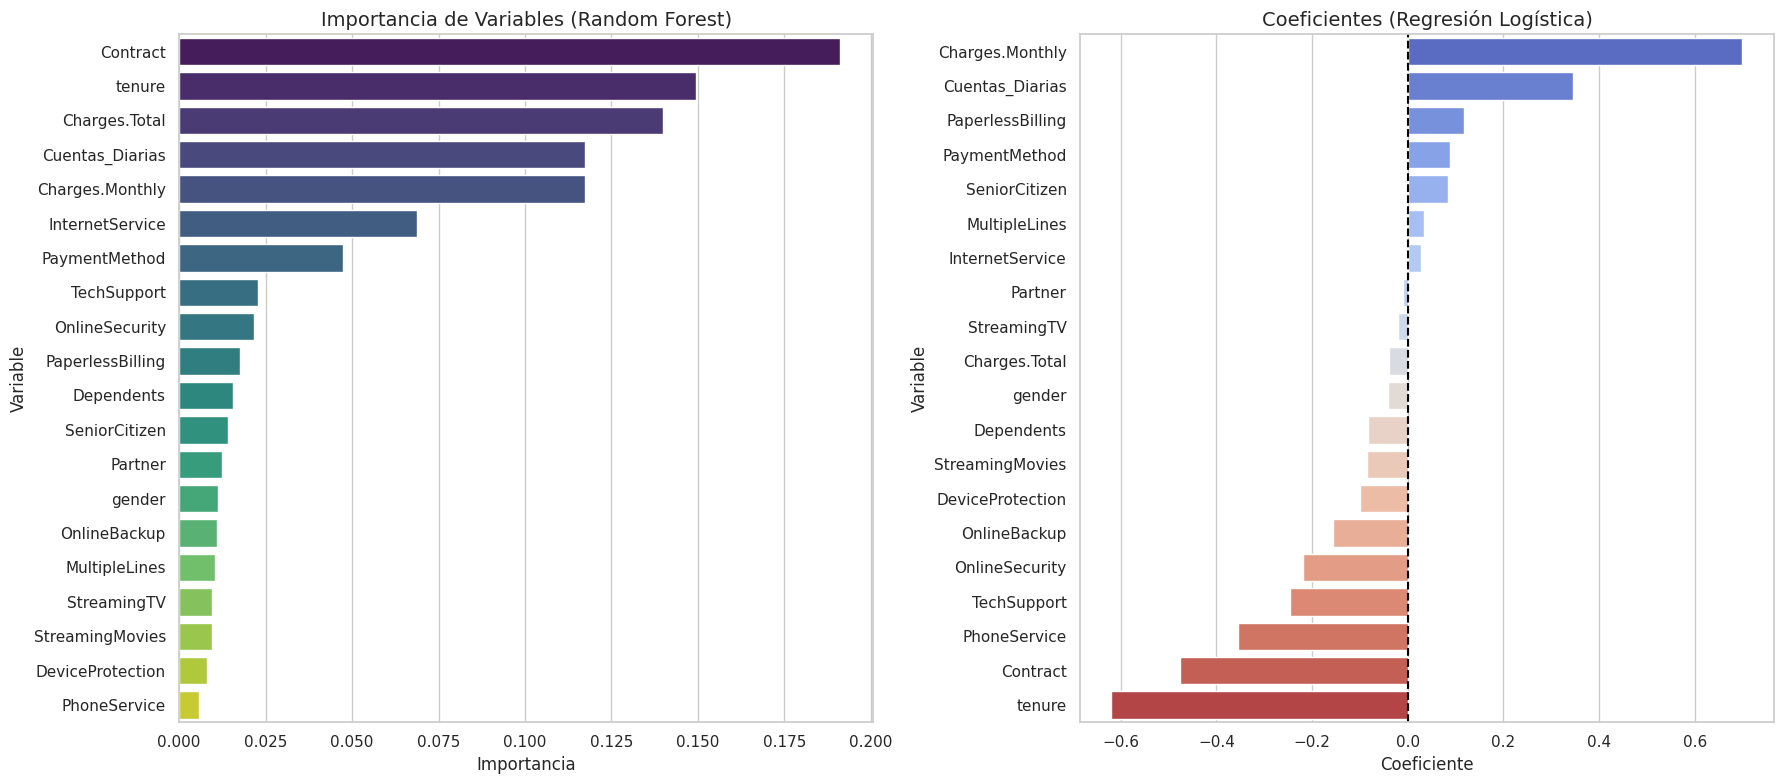

--- Top 5 Variables Predictoras ---
           Variable  Importancia
14         Contract     0.191110
4            tenure     0.149297
18    Charges.Total     0.139753
19  Cuentas_Diarias     0.117399
17  Charges.Monthly     0.117320


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Importancia de Variables en Random Forest
rf_importances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': final_rf_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# 2. Coeficientes en Regresión Logística
log_coefs = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': final_log_model.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Gráfico Random Forest
sns.barplot(data=rf_importances, x='Importancia', y='Variable', ax=axes[0], palette='viridis')
axes[0].set_title('Importancia de Variables (Random Forest)', fontsize=14)

# Gráfico Regresión Logística
sns.barplot(data=log_coefs, x='Coeficiente', y='Variable', ax=axes[1], palette='coolwarm')
axes[1].set_title('Coeficientes (Regresión Logística)', fontsize=14)
axes[1].axvline(0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

print("--- Top 5 Variables Predictoras ---")
print(rf_importances.head(5))

##Análisis de Relevancia de Variables:

### Preguntas y Respuestas

**¿Cuáles son los principales predictores de la fuga de clientes según los modelos entrenados?**
Basado en el análisis de importancia de características y coeficientes, los predictores más significativos son el tipo de contrato (específicamente los contratos mes a mes), el monto total de los cargos y la antigüedad (tenure) del cliente.

### Hallazgos Clave del Análisis de Datos

*   **Importancia en Random Forest:** Las tres características principales identificadas por el modelo son `Contract` (Tipo de Contrato), `tenure` (Antigüedad) y `Charges.Total` (Cargos Totales). Estas variables tienen el mayor poder predictivo sobre si un cliente se irá o no.
*   **Coeficientes de Regresión Logística:** El modelo muestra que los `Charges.Monthly` (Cargos Mensuales) tienen un coeficiente positivo alto, lo que indica que es el indicador más fuerte de riesgo de fuga entre las variables continuas.
*   **Factores Protectores:** Los contratos a largo plazo (`Two year`) y los servicios de seguridad muestran coeficientes negativos fuertes, lo que sugiere que estos clientes tienen significativamente menos probabilidades de abandonar.
*   **Alineación de Modelos:** Ambos modelos resaltan consistentemente que la duración de la relación (antigüedad) y el compromiso financiero (tipo de contrato/cargos) son los factores más críticos para determinar la lealtad del cliente.

### Insights y Próximos Pasos

*   **Retención Focalizada:** Dirigir campañas de marketing de retención a clientes con contratos "Mes a Mes", ya que representan el mayor riesgo de fuga según ambos modelos.
*   **Optimización de Valor:** Investigar la relación entre los cargos mensuales elevados y la fuga; los clientes con planes costosos pero poca antigüedad pueden estar experimentando un "choque de factura" que dispara su salida.